# Overall Summary

## Setup

Load [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension. 
This enables us to modify `.py` source files and reintegrate them into the notebook.


In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import libraries.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.stats import linregress
import pingouin as pg

Build dataframe

In [18]:
df = pd.read_csv("data.csv", encoding="utf-8-sig")
df.head()

,subj_id,age,gender,school_year,BIS,BIS_motor,BIS_nonplanning,BIS_attentional,STAI,STAI_S,...,action_Nothing_cnt,action_UP_cnt,action_DOWN_cnt,action_RIGHT_cnt,action_LEFT_cnt,visited_tile_cnt_mean,visited_unique_tile_cnt_mean,visited_tile_unique_ratio_mean,DDT_mean_log_k,CRA_mean_alpha
0,100,29,2,16,77,30,25,22,96,45,...,404,138,0,650,656,53.962963,18.148148,0.344531,-6.945853,0.851175
1,502,19,2,12,79,31,25,23,104,51,...,26,2030,48,348,569,29.520000,28.070000,0.957723,-4.945853,0.751175
2,503,30,1,1234,80,36,24,20,109,56,...,32,2435,71,486,608,36.130000,34.030000,0.948767,-2.945853,1.111751


Utils

In [19]:
def print_summary(data, name):
    print(f"{name}: mean = {data.mean():.2f}, std = {data.std():.2f} (min={data.min()} ~ max={data.max()})")

def plot_summary(plot, data, title, bins=10):
    plot.hist(data, bins=bins, edgecolor="black")
    plot.set_xlabel(title)
    plot.set_ylabel("Frequency")
    plot.set_title(title)

def scatter_plot_with_line_regression(plot, x, y, xlabel, ylabel, title):
    plot.scatter(x, y)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept
    plot.plot(line_x, line_y, color="red")

    plot.set_xlabel(xlabel)
    plot.set_ylabel(ylabel)
    plot.set_title(f"{title}\nr={r_value:.3f}")

## Survey

### Demographics

Age: mean = 26.00, std = 6.08 (min=19 ~ max=30)
2 males & 1 females


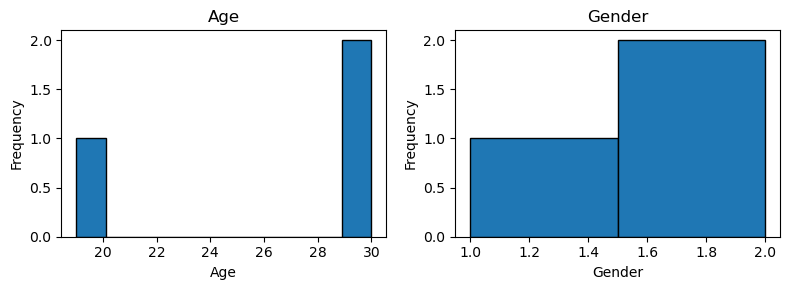

In [20]:
print_summary(df["age"], "Age")
print(f"{len(df[df['gender'] == 2])} males & {len(df[df['gender'] == 1])} females")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_summary(axes[0], df["age"], "Age")
plot_summary(axes[1], df["gender"], "Gender", bins=2)
plt.tight_layout()
plt.show()

### BIS

BIS: mean = 78.67, std = 1.53 (min=77 ~ max=80)
BIS_motor: mean = 32.33, std = 3.21 (min=30 ~ max=36)
BIS_nonplanning: mean = 24.67, std = 0.58 (min=24 ~ max=25)
BIS_attentional: mean = 21.67, std = 1.53 (min=20 ~ max=23)


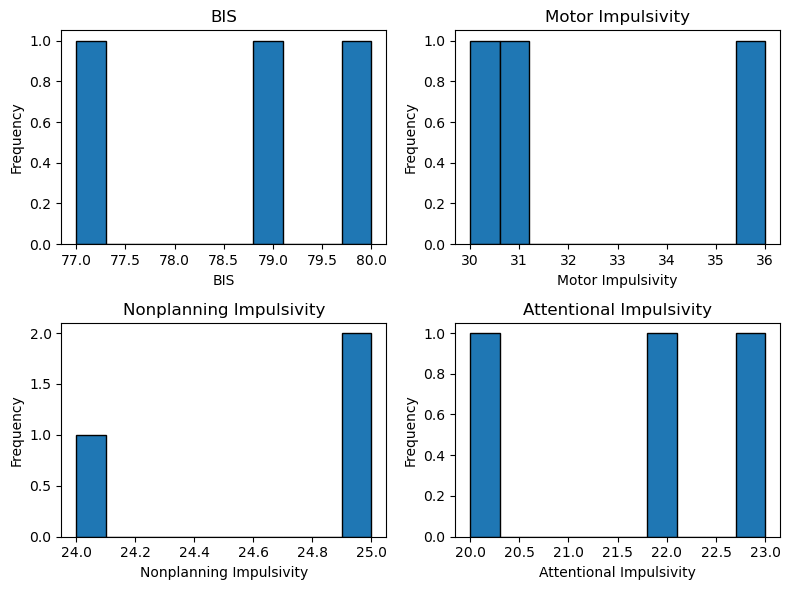

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for i in range(4):
    col = ["BIS", "BIS_motor", "BIS_nonplanning", "BIS_attentional"][i]
    title = ["BIS", "Motor Impulsivity", "Nonplanning Impulsivity", "Attentional Impulsivity"][i]
    print_summary(df[col], col)
    plot_summary(axes[i // 2, i % 2], df[col], title)
plt.tight_layout()
plt.show()

### STAI

STAI: mean = 103.00, std = 6.56 (min=96 ~ max=109)
STAI_S: mean = 50.67, std = 5.51 (min=45 ~ max=56)
STAI_T: mean = 52.33, std = 1.15 (min=51 ~ max=53)


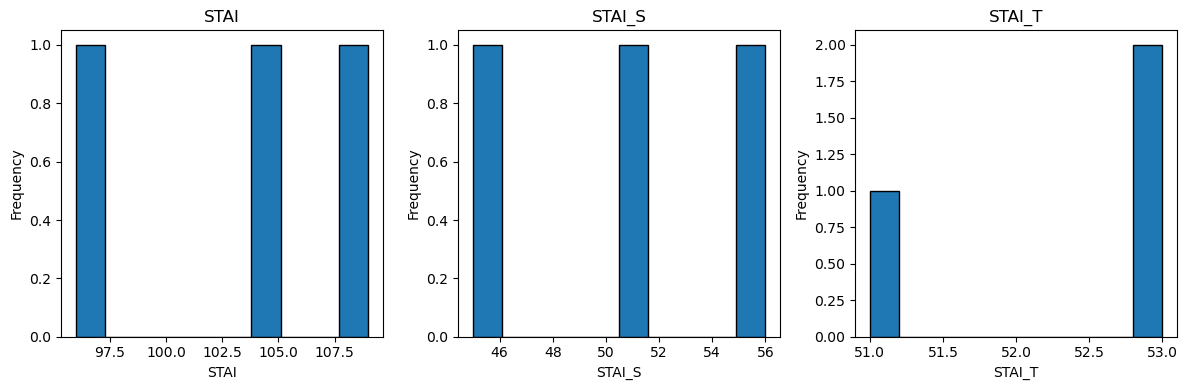

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    col = ["STAI", "STAI_S", "STAI_T"][i]
    print_summary(df[col], col)
    plot_summary(axes[i], df[col], col)
plt.tight_layout()
plt.show()

### DOSPERT

DOSPERT: mean = 106.33, std = 16.20 (min=96 ~ max=125)
DOSPERT_ETH: mean = 18.33, std = 5.51 (min=13 ~ max=24)
DOSPERT_FIN: mean = 22.67, std = 3.79 (min=20 ~ max=27)
DOSPERT_HEA: mean = 22.00, std = 4.36 (min=17 ~ max=25)
DOSPERT_REC: mean = 22.67, std = 3.21 (min=19 ~ max=25)
DOSPERT_SOC: mean = 20.67, std = 4.16 (min=16 ~ max=24)


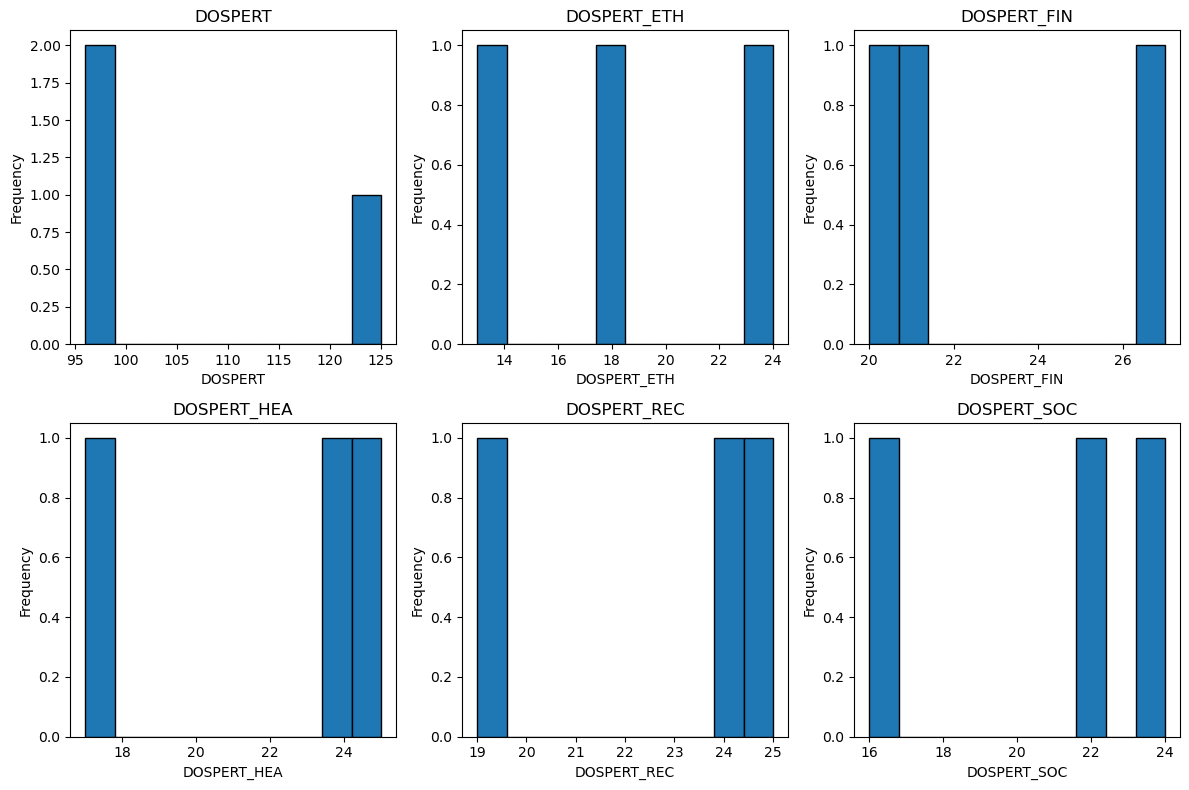

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    col = ["DOSPERT", "DOSPERT_ETH", "DOSPERT_FIN", "DOSPERT_HEA", "DOSPERT_REC", "DOSPERT_SOC"][i]
    title = ["DOSPERT", "Ethical Risk Taking", "Financial Risk Taking", "Health and Safety Risk Taking", "Recreational Risk Taking", "Social Risk Taking"][i]
    print_summary(df[col], col)
    plot_summary(axes[i // 3, i % 3], df[col], col)
plt.tight_layout()
plt.show()

### CES-D

CES-D: mean = 53.00, std = 0.00 (min=53 ~ max=53)


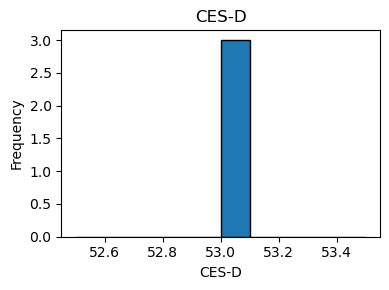

In [24]:
print_summary(df["CES_D"], "CES-D")
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
plot_summary(axes, df["CES_D"], "CES-D")
plt.tight_layout()
plt.show()

## Traditional Behavior Tasks

DDT - Discounting Rate (log k): mean = -4.95, std = 2.00 (min=-6.945852756500244 ~ max=-2.945852756500244)
CRA - Risk Preference (alpha): mean = 0.90, std = 0.19 (min=0.7511751294136046 ~ max=1.111751294136047)


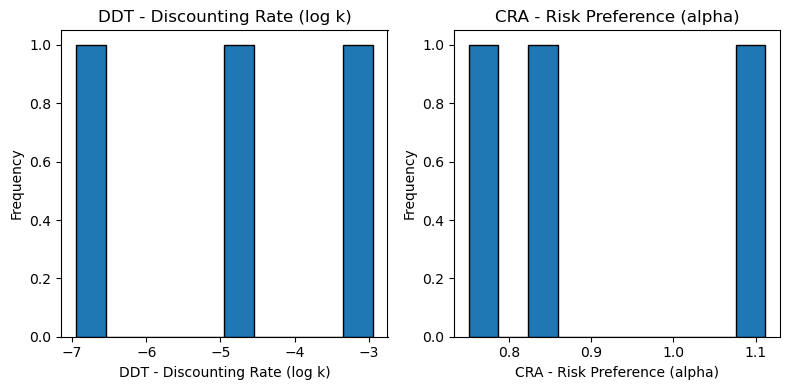

In [25]:
print_summary(df["DDT_mean_log_k"], "DDT - Discounting Rate (log k)")
print_summary(df["CRA_mean_alpha"], "CRA - Risk Preference (alpha)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_summary(axes[0], df["DDT_mean_log_k"], "DDT - Discounting Rate (log k)")
plot_summary(axes[1], df["CRA_mean_alpha"], "CRA - Risk Preference (alpha)")
plt.tight_layout()
plt.show()

## Pedestrian Task

### Scores

Total Score: mean = 128900.00, std = 105869.48 (min=6800 ~ max=195150)
Best Score: mean = 1900.00, std = 435.89 (min=1400 ~ max=2200)
Mean Score: mean = 1350.28, std = 952.69 (min=251.85185185185185 ~ max=1951.5)
STD Score: mean = 362.24, std = 48.79 (min=306.20312463355685 ~ max=395.3246332529326)


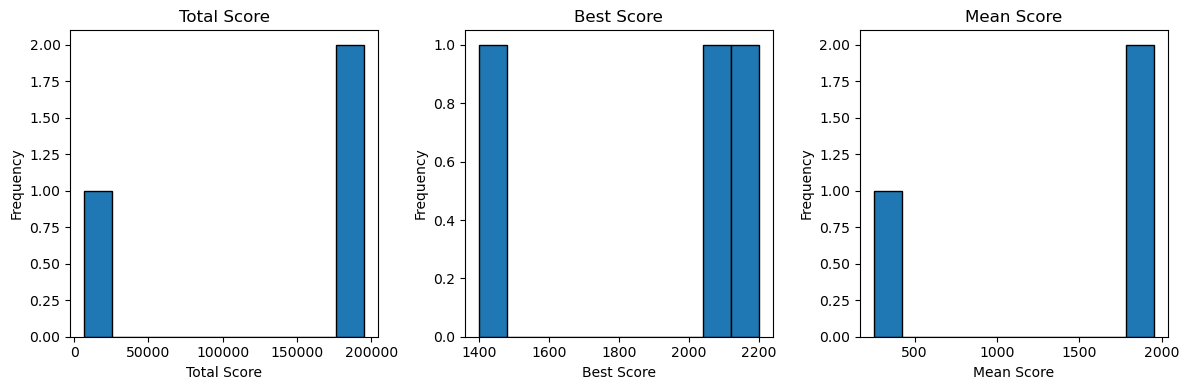

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    col = ["total_score_full", "best_score_full", "average_score_full"][i]
    title = ["Total Score", "Best Score", "Mean Score"][i]
    print_summary(df[col], title)
    plot_summary(axes[i], df[col], title)
print_summary(df['std_score_full'], "STD Score")
plt.tight_layout()
plt.show()

### Split-half Reliability

- ICC(3,1) reflects the degree of absolute agreement between two **fixed** raters, indicating how consistent the scores from Session 1 and Session 2 are for each participant
- Ssould be at least 0.5, but needs enough sample size (N)
- "The split-half reliability between the scores in the first half and the second half of the task assessed by the intraclass correlation coefficient (Koo & Li, 2016) was .72, which is acceptable." (Lee et al., 2014)

In [42]:
print_summary(df['total_score_session1'], "Total Score (Session 1")
print_summary(df['total_score_session2'], "Total Score (Session 2)")

total_length = len(df["subj_id"])
df_total = pd.DataFrame({
    'subject': np.repeat(df['subj_id'].values, 2),
    'rater':   np.tile(['first', 'second'], total_length),
    'score':   np.concatenate([df['total_score_session1'].values, df['total_score_session2'].values])
})
icc_table = pg.intraclass_corr(data=df_total, targets='subject', raters='rater', ratings='score')
icc3 = icc_table.loc[icc_table["Type"] == "ICC3"]
print(f"ICC = {icc3['ICC'].values[0]:.2f}")
icc3

Total Score (Session 1: mean = 66850.00, std = 52404.08 (min=6350 ~ max=98100)
Total Score (Session 2): mean = 62050.00, std = 53512.24 (min=450 ~ max=97050)
ICC = -0.57


,Type,Description,ICC,F,df1,df2,pval,CI95%
2,ICC3,Single fixed raters,-0.569312,0.274444,2,2,0.784656,"[-0.99, 0.83]"


In [43]:
print_summary(df['average_score_session1'], "Score Mean (Session 1)")
print_summary(df['average_score_session2'], "Score Mean (Session 2)")

total_length = len(df["subj_id"])
df_total = pd.DataFrame({
    'subject': np.repeat(df['subj_id'].values, 2),
    'rater':   np.tile(['first', 'second'], total_length),
    'score':   np.concatenate([df['average_score_session1'].values, df['average_score_session2'].values])
})
icc_table = pg.intraclass_corr(data=df_total, targets='subject', raters='rater', ratings='score')
icc3 = icc_table.loc[icc_table["Type"] == "ICC3"]
print(f"ICC = {icc3['ICC'].values[0]:.2f}")
icc3

Score Mean (Session 1): mean = 1376.08, std = 980.41 (min=244.23076923076923 ~ max=1962.0)
Score Mean (Session 2): mean = 1388.00, std = 816.66 (min=450 ~ max=1941)
ICC = -0.57


,Type,Description,ICC,F,df1,df2,pval,CI95%
2,ICC3,Single fixed raters,-0.57265,0.271739,2,2,0.786325,"[-0.99, 0.83]"


### Crosswalk usage
- TODO

### Game over status
- TODO

### Locomotor Statistics
- Action Proportions
- Number of visited tiles